# **Analysis of Security Logs for Suspicious Activity**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/login data set')
df

,timestamp,username,ip_address,login_status,attempt_count,device,location
0,01-08-2026 07:23,eodriscoll,10.0.3.175,success,1,MAC-DEV07,"London, UK"
1,01-08-2026 08:45,akumar,10.0.7.116,success,1,DESKTOP-B77,"New York, US"
2,01-08-2026 08:54,jsmith,10.0.2.13,failed,1,WORKSTN-22,"Sydney, AU"
3,01-08-2026 08:55,jsmith,10.0.2.13,success,2,WORKSTN-22,"Sydney, AU"
4,01-08-2026 08:56,dwilliams,10.0.2.220,success,1,SRV-WEB01,"New York, US"
...,...,...,...,...,...,...,...
495,21-08-2026 17:32,sono,10.0.7.131,success,1,SRV-DB02,"Mumbai, IN"
496,21-08-2026 17:38,lchen,192.168.1.43,success,1,WORKSTN-45,"New York, US"
497,21-08-2026 19:26,fmartin,192.168.0.157,success,1,VPN-GATE01,"Sydney, AU"
498,21-08-2026 19:36,kmoreno,10.0.20.30,success,1,SRV-DB02,"Berlin, DE"


How many login failures happened ?

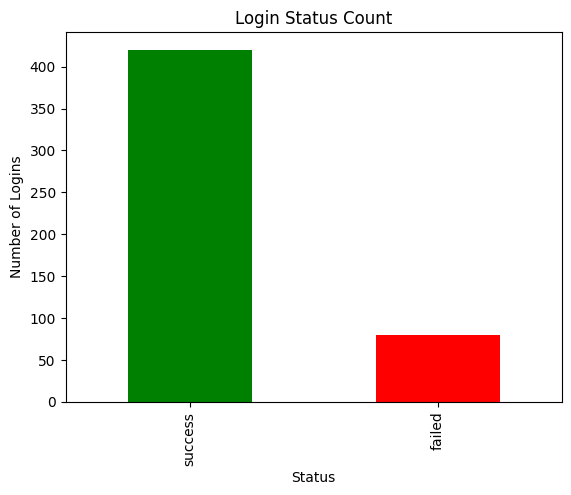

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Count failed vs success
df['login_status'].value_counts().plot(kind='bar', color=['green', 'red'])

plt.title('Login Status Count')
plt.xlabel('Status')
plt.ylabel('Number of Logins')
plt.show()

Which username had the most failed attempts?

Most failed attempts: lpetrov - 14


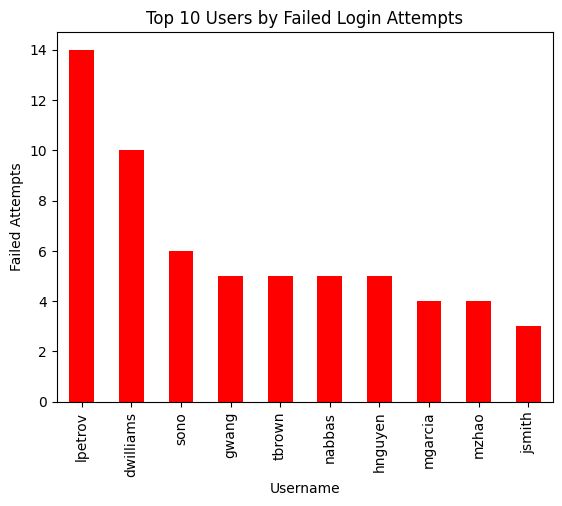

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Count failed logins per user
failed_by_user = df[df['login_status'] == 'failed']['username'].value_counts()

print("Most failed attempts:", failed_by_user.idxmax(), "-", failed_by_user.max())

# Bar chart of top 10 users
failed_by_user.head(10).plot(kind='bar', color='red')
plt.title('Top 10 Users by Failed Login Attempts')
plt.xlabel('Username')
plt.ylabel('Failed Attempts')
plt.show()

Which IP address appears most often?

In [10]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/login data set')

top_ip = df['ip_address'].value_counts()

print("Most frequent IP:", top_ip.idxmax(), "-", top_ip.max(), "times")

Most frequent IP: 192.168.5.45 - 16 times


At what time did suspicious activity increase?

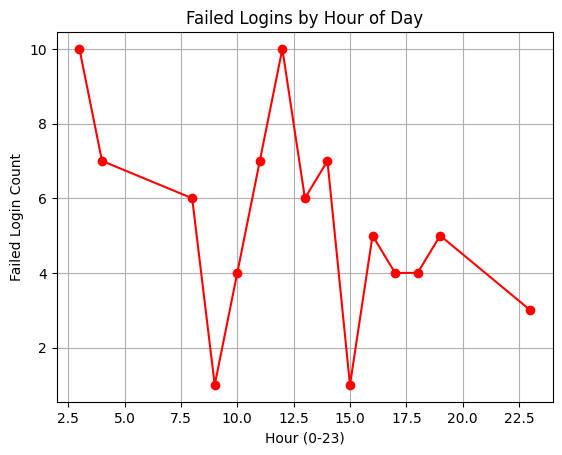

Peak suspicious hour: 3 with 10 failures


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Convert to datetime and extract hour with explicit format
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')
df['hour'] = df['timestamp'].dt.hour

# Count failed logins per hour
failed_by_hour = df[df['login_status'] == 'failed'].groupby('hour').size()

# Line chart - best for showing trend/spike over time
failed_by_hour.plot(kind='line', marker='o', color='red')
plt.title('Failed Logins by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Failed Login Count')
plt.grid(True)
plt.show()

print("Peak suspicious hour:", failed_by_hour.idxmax(), "with", failed_by_hour.max(), "failures")

Is there a brute-force attack pattern?

In [13]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Brute-force = same user + same IP with 5+ failed attempts
failed = df[df['login_status'] == 'failed']
brute_force = failed.groupby(['username', 'ip_address']).size()
brute_force = brute_force[brute_force >= 5]

print("Possible brute-force attacks (user, IP -> failed attempts):")
print(brute_force)

Possible brute-force attacks (user, IP -> failed attempts):
username   ip_address   
dwilliams  103.219.145.9     7
lpetrov    141.98.11.100    10
dtype: int64


Are there many failures before a success?

Average attempts before success: 1.14
Max attempts before a success: 2


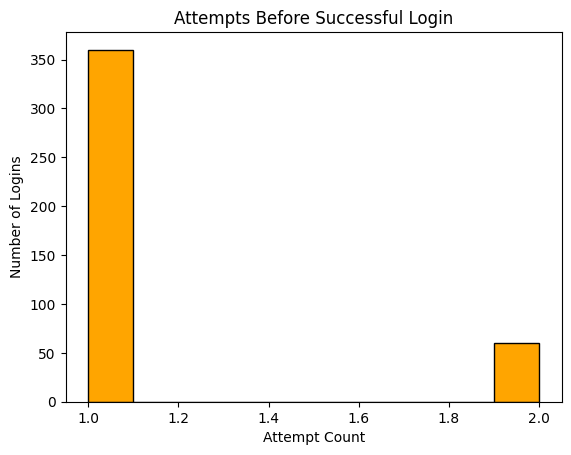

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/login data set')

# attempt_count at the moment of success tells how many tries it took
success_attempts = df[df['login_status'] == 'success']['attempt_count']

print("Average attempts before success:", success_attempts.mean().round(2))
print("Max attempts before a success:", success_attempts.max())

# Histogram - best to show distribution of attempts-before-success
success_attempts.plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Attempts Before Successful Login')
plt.xlabel('Attempt Count')
plt.ylabel('Number of Logins')
plt.show()

Did one account show too many access attempts?

In [15]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Total access attempts (success + failed) per user
attempts_per_user = df['username'].value_counts()

print("Most active account:", attempts_per_user.idxmax(), "-", attempts_per_user.max(), "attempts")

# Flag accounts with unusually high attempts (e.g. more than 20)
suspicious = attempts_per_user[attempts_per_user > 20]
print("\nAccounts with unusually high activity:")
print(suspicious)

Most active account: lpetrov - 35 attempts

Accounts with unusually high activity:
username
lpetrov       35
dwilliams     32
tbrown        32
jkovac        31
nkhan         30
rpatel        27
kmoreno       27
akumar        26
gwang         26
hnguyen       26
fmartin       25
nabbas        24
mgarcia       23
eodriscoll    22
sono          22
mzhao         22
lchen         21
Name: count, dtype: int64


Which device or host shows unusual behavior?

In [16]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/login data set')

# Failed logins per device
failed_by_device = df[df['login_status'] == 'failed']['device'].value_counts()

print("Device with most failed logins:", failed_by_device.idxmax(), "-", failed_by_device.max())
print("\nAll devices with failed logins:")
print(failed_by_device)

Device with most failed logins: DESKTOP-B77 - 17

All devices with failed logins:
device
DESKTOP-B77     17
DESKTOP-A12      8
SRV-WEB01        8
VPN-GATE01       7
LAPTOP-HR03      7
LAPTOP-FIN11     7
ADMIN-PC01       6
MAC-DEV19        5
WORKSTN-45       4
WORKSTN-22       3
SRV-APP03        3
SRV-DB02         2
MAC-DEV07        2
TABLET-09        1
Name: count, dtype: int64


## **Overview**
1. How many login failures happened?
Out of 500 total login records, 80 were failed attempts and 420 were successful, meaning about 16% of all logins failed — a notable share worth investigating further.

2. Which username had the most failed attempts?
The user lpetrov had the highest number of failed login attempts, with 14 failures — significantly more than other users, making this account a top concern.

3. Which IP address appears most often?
The IP 192.168.5.45 was the most frequently seen address, appearing 16 times across the logs.

4. At what time did suspicious activity increase?
Failed login attempts spiked around 3 AM, with 10 failures recorded in that hour alone — a strong indicator of automated or off-hours attack activity, since legitimate users rarely log in at that time.

5. Is there a brute-force attack pattern?
Yes. Two username-IP combinations crossed the brute-force threshold (5+ failed attempts from the same IP):
lpetrov from IP 141.98.11.100 — 10 failed attempts
dwilliams from IP 103.219.145.9 — 7 failed attempts
This is a classic brute-force signature — the same account being repeatedly targeted from a single external IP.

6. Are there many failures before a success?
Not significantly. On average, successful logins took only ~1.14 attempts, with a maximum of 2 attempts before success. This suggests most successful logins are legitimate first-or-second-try logins, not the result of a drawn-out brute-force success.

7. Did one account show too many access attempts?
Yes — lpetrov also had the highest total activity overall, with 35 access attempts (success + failed combined), far above the average user, reinforcing that this account is the most targeted or compromised.

8. Which device or host shows unusual behavior?
The device DESKTOP-B77 recorded the most failed login attempts (17), making it the most suspicious endpoint in the dataset.

9. Were there repeated logins from different locations?
Yes — nearly all users logged in from multiple locations (6–9 different locations each), with dwilliams and lpetrov topping the list at 9 locations apiece. This kind of geographic spread, especially combined with their high failure counts, suggests possible credential sharing, VPN abuse, or account compromise.

Overall Conclusion:
The account lpetrov stands out as the primary suspect for suspicious activity — it has the most failed attempts, the highest total access volume, was targeted in a clear brute-force pattern from IP 141.98.11.100, and logged in from 9 different locations. Combined with the after-hours spike at 3 AM and device DESKTOP-B77's high failure count, the data points to a coordinated brute-force attempt against a small set of accounts rather than random, scattered failures.